# Spatio-Temporal Crop Health Assessment for the Jammu Region
## Dissertation Pipeline

This notebook implements the complete end-to-end workflow for:
- satellite data extraction
- spatio-temporal analysis
- crop health modeling
- deep learning–based forecasting

Study Area: Jammu Region (India)  
Time Period: 2017–2025 (Kharif Season)


In [ ]:
# Core geospatial & data libraries
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Visualization settings
plt.style.use("seaborn-v0_8")


In [ ]:
# Authenticate Earth Engine
ee.Authenticate()

# Initialize with your project
ee.Initialize(project="gee-jammu-dissertation")

print("Earth Engine initialized successfully")


Earth Engine initialized successfully


In [ ]:
# ---------------------------------------------------
# Define Jammu study region (bounding box)
# ---------------------------------------------------
jammu = ee.Geometry.Rectangle(
    [74.5, 32.5,   # min longitude, min latitude
     75.9, 33.5]   # max longitude, max latitude
)


In [ ]:
# ---------------------------------------------------
# Generate 150 fixed spatial sampling points
# ---------------------------------------------------
NUM_POINTS = 200

points_fc = ee.FeatureCollection.randomPoints(
    region=jammu,
    points=NUM_POINTS,
    seed=42  # ensures reproducibility
)

print("Number of sampling points:",
      points_fc.size().getInfo())


Number of sampling points: 200


In [ ]:
# ---------------------------------------------------
# Visualize study region and sampling points
# ---------------------------------------------------
Map = geemap.Map(center=[33.0, 75.2], zoom=8)

Map.addLayer(jammu, {}, "Jammu Study Boundary")
Map.addLayer(points_fc, {"color": "red"}, "150 Sampling Points")

Map


Map(center=[33.0, 75.2], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(…

## WP0 Status
- Environment initialized ✔
- Jammu study region defined ✔
- 150 fixed spatial sampling points generated ✔
- Visual verification completed ✔


WP0  → Environment & GEE auth          ✔ already done

WP1  → Spatio-temporal data extraction ← WE START HERE

WP1-A → Sentinel-2 indices (core)

WP1-B → MODIS LST + anomaly

WP1-C → Rainfall + lagged rainfall

Pre-WP2 → Analytics, maps, sanity plots

WP2  → Crop Health Score (regression)

WP3  → Deep Learning forecasting


In [ ]:
YEARS = list(range(2017, 2026))
MONTHS = [6, 7, 8, 9]   # Kharif season


In [ ]:
# Generate 200 random sampling points inside Jammu boundary
points_fc = ee.FeatureCollection.randomPoints(
    region=jammu,
    points=200,
    seed=42
)

points_fc.size().getInfo()


200

In [ ]:
def add_point_id(feature):
    return feature.set("point_id", ee.Number.parse(feature.id()))

points_fc = points_fc.map(add_point_id)

points_fc.first().getInfo()


{'type': 'Feature',
 'geometry': {'type': 'Point',
  'coordinates': [74.90107466833132, 33.19195280079289]},
 'id': '0',
 'properties': {'point_id': 0}}

In [ ]:
def add_s2_indices(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    ndmi = image.normalizedDifference(["B8", "B11"]).rename("NDMI")
    ndwi = image.normalizedDifference(["B3", "B8"]).rename("NDWI")

    evi = image.expression(
        "2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))",
        {
            "NIR": image.select("B8"),
            "RED": image.select("B4"),
            "BLUE": image.select("B2")
        }
    ).rename("EVI")

    return image.addBands([ndvi, ndmi, ndwi, evi])


In [ ]:
def extract_monthly_s2(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(start, end)
        .filterBounds(jammu)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 40))
        .map(lambda img: img.multiply(0.0001))
        .map(add_s2_indices)
    )

    return ee.Algorithms.If(
        s2.size().gt(0),
        s2.median()
        .select(["NDVI", "NDMI", "NDWI", "EVI"])
        .sampleRegions(
            collection=points_fc,
            scale=10,
            geometries=False
        ),
        None
    )


In [ ]:
def s2_samples_to_records(fc, year, month):
    feats = fc.getInfo()["features"]
    records = []

    for f in feats:
        p = f["properties"]
        records.append({
            "Year": year,
            "Month": month,
            "point_id": p.get("point_id"),
            "NDVI": p.get("NDVI"),
            "NDMI": p.get("NDMI"),
            "NDWI": p.get("NDWI"),
            "EVI": p.get("EVI"),
        })

    return records


In [ ]:
s2_records = []

for year in YEARS:
    for month in MONTHS:
        print(f"Sentinel-2: {year}-{month}")
        try:
            result = extract_monthly_s2(year, month)
            if result is None:
                print("  → No images")
                continue

            fc = ee.FeatureCollection(result)
            recs = s2_samples_to_records(fc, year, month)
            s2_records.extend(recs)

            print(f"  → {len(recs)} samples")

        except Exception as e:
            print(f"  ⚠️ Error: {e}")


Sentinel-2: 2017-6
  → 1 samples
Sentinel-2: 2017-7
  ⚠️ Error: 'NoneType' object is not subscriptable
Sentinel-2: 2017-8
  ⚠️ Error: 'NoneType' object is not subscriptable
Sentinel-2: 2017-9
  → 21 samples
Sentinel-2: 2018-6
  → 81 samples
Sentinel-2: 2018-7
  ⚠️ Error: 'NoneType' object is not subscriptable
Sentinel-2: 2018-8
  ⚠️ Error: 'NoneType' object is not subscriptable
Sentinel-2: 2018-9
  ⚠️ Error: 'NoneType' object is not subscriptable
Sentinel-2: 2019-6
  → 200 samples
Sentinel-2: 2019-7
  → 200 samples
Sentinel-2: 2019-8
  → 200 samples
Sentinel-2: 2019-9
  → 200 samples
Sentinel-2: 2020-6
  → 200 samples
Sentinel-2: 2020-7
  → 200 samples
Sentinel-2: 2020-8
  → 200 samples
Sentinel-2: 2020-9
  → 200 samples
Sentinel-2: 2021-6
  → 200 samples
Sentinel-2: 2021-7
  → 200 samples
Sentinel-2: 2021-8
  → 200 samples
Sentinel-2: 2021-9
  → 200 samples
Sentinel-2: 2022-6
  → 200 samples
Sentinel-2: 2022-7
  → 136 samples
Sentinel-2: 2022-8
  → 200 samples
Sentinel-2: 2022-9
  → 2

In [ ]:
df_s2 = pd.DataFrame(s2_records)

df_s2.shape
df_s2.head()
##df_s2.describe()


,Year,Month,point_id,NDVI,NDMI,NDWI,EVI
0,2017,6,114,0.086116,-0.135664,-0.211290,0.066468
1,2017,9,5,0.852744,0.379585,-0.736948,0.593552
2,2017,9,22,0.891156,0.376522,-0.790660,0.607983
3,2017,9,37,-0.051997,-0.040061,0.034536,-0.032443
4,2017,9,41,0.809935,0.300990,-0.697215,0.565654


In [ ]:
df_s2[["NDVI", "EVI", "NDMI", "NDWI"]].describe()


,NDVI,EVI,NDMI,NDWI
count,5541.000000,5541.000000,5541.000000,5541.000000
mean,0.500486,0.384090,0.147926,-0.455228
std,0.257669,0.921349,0.128829,0.222156
min,-1.000000,-4.350000,-0.370213,-0.878797
25%,0.330821,0.254395,0.064046,-0.627309
50%,0.543709,0.377447,0.154734,-0.510125
75%,0.720765,0.502306,0.239420,-0.327028
max,0.907016,64.935924,0.902561,1.000000


In [ ]:
points_fc.first().getInfo()


{'type': 'Feature',
 'geometry': {'type': 'Point',
  'coordinates': [74.90107466833132, 33.19195280079289]},
 'id': '0',
 'properties': {'point_id': 0}}

In [ ]:
# MODIS LST validity mask
lst_valid_mask = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .select("LST_Day_1km")
    .mean()
    .mask()
)


In [ ]:
points_lst_valid = points_fc.filterBounds(
    lst_valid_mask.geometry()
)

points_lst_valid.size().getInfo()


200

In [ ]:
buffered_points_lst = points_lst_valid.map(
    lambda f: f.buffer(1000)   # 1 km buffer
)


In [ ]:
def extract_monthly_lst(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    lst_ic = (
        ee.ImageCollection("MODIS/061/MOD11A2")
        .filterDate(start, end)
        .filterBounds(jammu)
        .select("LST_Day_1km")
    )

    return ee.Algorithms.If(
        lst_ic.size().gt(0),
        lst_ic.mean()
        .multiply(0.02)        # scale factor
        .subtract(273.15)      # Kelvin → Celsius
        .rename("LST")
        .reduceRegions(
            collection=buffered_points_lst,
            reducer=ee.Reducer.mean(),
            scale=1000
        ),
        None
    )


In [ ]:
test_fc = ee.FeatureCollection(extract_monthly_lst(2022, 7))

test_fc.size().getInfo()


200

In [ ]:
test_fc.first().getInfo()


{'type': 'Feature',
 'geometry': {'type': 'Polygon',
  'coordinates': [[[74.90107466833298, 33.2009516667437],
    [74.8980708109932, 33.200593475805974],
    [74.89530612960837, 33.19954742337988],
    [74.89300074021304, 33.19789679778463],
    [74.891338162891, 33.1957730184818],
    [74.89045071012241, 33.19334516582589],
    [74.89040896366916, 33.19080651367873],
    [74.89121617483637, 33.18835913957293],
    [74.8928080280477, 33.1861978390876],
    [74.89505777957037, 33.18449462492861],
    [74.89778635635939, 33.18338504308419],
    [74.9007766080259, 33.182957392679],
    [74.90379057817879, 33.183245704721756],
    [74.90658842465434, 33.1842270363443],
    [74.90894748916185, 33.18582329494241],
    [74.91068000519421, 33.18790744767461],
    [74.91164803954743, 33.19031362412302],
    [74.91177447957222, 33.19285031079811],
    [74.91104918915535, 33.19531558994459],
    [74.90952983786147, 33.19751321140958],
    [74.90733733027542, 33.19926821849972],
    [74.904646193

In [ ]:
def lst_samples_to_records(fc, year, month):
    feats = fc.getInfo()["features"]
    records = []

    for f in feats:
        p = f["properties"]
        records.append({
            "Year": year,
            "Month": month,
            "point_id": p.get("point_id"),
            "LST": p.get("mean")
        })

    return records


In [ ]:
lst_records = []

for year in YEARS:
    for month in MONTHS:
        print(f"LST: {year}-{month}")
        try:
            result = extract_monthly_lst(year, month)
            if result is None:
                print("  → No data")
                continue

            fc = ee.FeatureCollection(result)
            recs = lst_samples_to_records(fc, year, month)
            lst_records.extend(recs)

            print(f"  → {len(recs)} samples")

        except Exception as e:
            print(f"  ⚠️ Error: {e}")


LST: 2017-6
  → 200 samples
LST: 2017-7
  → 200 samples
LST: 2017-8
  → 200 samples
LST: 2017-9
  → 200 samples
LST: 2018-6
  → 200 samples
LST: 2018-7
  → 200 samples
LST: 2018-8
  → 200 samples
LST: 2018-9
  → 200 samples
LST: 2019-6
  → 200 samples
LST: 2019-7
  → 200 samples
LST: 2019-8
  → 200 samples
LST: 2019-9
  → 200 samples
LST: 2020-6
  → 200 samples
LST: 2020-7
  → 200 samples
LST: 2020-8
  → 200 samples
LST: 2020-9
  → 200 samples
LST: 2021-6
  → 200 samples
LST: 2021-7
  → 200 samples
LST: 2021-8
  → 200 samples
LST: 2021-9
  → 200 samples
LST: 2022-6
  → 200 samples
LST: 2022-7
  → 200 samples
LST: 2022-8
  → 200 samples
LST: 2022-9
  → 200 samples
LST: 2023-6
  → 200 samples
LST: 2023-7
  → 200 samples
LST: 2023-8
  → 200 samples
LST: 2023-9
  → 200 samples
LST: 2024-6
  → 200 samples
LST: 2024-7
  → 200 samples
LST: 2024-8
  → 200 samples
LST: 2024-9
  → 200 samples
LST: 2025-6
  → 200 samples
LST: 2025-7
  → 200 samples
LST: 2025-8
  → 200 samples
LST: 2025-9
  → 200 

In [ ]:
df_lst = pd.DataFrame(lst_records)

df_lst.shape
df_lst.head()
df_lst["LST"].describe()


,LST
count,7200.000000
mean,25.735449
std,6.090730
min,6.410731
25%,21.215754
50%,26.401993
75%,29.439919
max,47.356426


In [ ]:
df_lst.to_csv(
    "/content/drive/MyDrive/crop_health_jammu/data/WP1_B_LST_pointid.csv",
    index=False
)


In [ ]:
df_s2.to_csv(
    "/content/drive/MyDrive/crop_health_jammu/data/WP1_A_S2_pointid.csv",
    index=False
)

In [ ]:
df_s2 = pd.read_csv(
    "/content/drive/MyDrive/crop_health_jammu/data/WP1_A_S2_pointid.csv"
)

df_lst = pd.read_csv(
    "/content/drive/MyDrive/crop_health_jammu/data/WP1_B_LST_pointid.csv"
)

print(df_s2.shape, df_lst.shape)


(5541, 7) (7200, 4)


In [ ]:
df_merged = pd.merge(
    df_s2,
    df_lst,
    on=["Year", "Month", "point_id"],
    how="inner"
)

print("Merged shape:", df_merged.shape)


Merged shape: (5541, 8)


In [ ]:
df_merged["LST"].describe()


,LST
count,5541.000000
mean,25.953146
std,6.157630
min,6.410731
25%,21.416766
50%,26.581581
75%,29.628017
max,47.356426


In [ ]:
lst_climatology = (
    df_merged
    .groupby("Month")["LST"]
    .mean()
)


In [ ]:
df_merged["LST_anomaly"] = df_merged.apply(
    lambda r: r["LST"] - lst_climatology[r["Month"]],
    axis=1
)


In [ ]:
df_merged[["LST", "LST_anomaly"]].describe()


,LST,LST_anomaly
count,5541.000000,5.541000e+03
mean,25.953146,-8.206955e-16
std,6.157630,5.695362e+00
min,6.410731,-2.333118e+01
25%,21.416766,-4.464142e+00
50%,26.581581,1.051584e+00
75%,29.628017,4.237385e+00
max,47.356426,1.761451e+01


In [ ]:
df_merged.to_csv(
    "/content/drive/MyDrive/crop_health_jammu/data/WP1_B_S2_LST_ANOMALY_pointid.csv",
    index=False
)

print("WP1-B final dataset saved")


WP1-B final dataset saved


In [ ]:
df_base = pd.read_csv(
    "/content/drive/MyDrive/crop_health_jammu/data/WP1_B_S2_LST_ANOMALY_pointid.csv"
)

print(df_base.shape)
df_base.head()


(5541, 9)


,Year,Month,point_id,NDVI,NDMI,NDWI,EVI,LST,LST_anomaly
0,2017,6,114,0.086116,-0.135664,-0.211290,0.066468,38.217218,8.475307
1,2017,9,5,0.852744,0.379585,-0.736948,0.593552,30.070230,5.778549
2,2017,9,22,0.891156,0.376522,-0.790660,0.607983,28.918222,4.626541
3,2017,9,37,-0.051997,-0.040061,0.034536,-0.032443,28.082212,3.790532
4,2017,9,41,0.809935,0.300990,-0.697215,0.565654,29.753452,5.461772


In [ ]:
# ---------------------------------------------------
# Extract monthly CHIRPS rainfall (mm)
# ---------------------------------------------------
def extract_monthly_rainfall(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    chirps = (
        ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
        .filterDate(start, end)
        .filterBounds(jammu)
        .sum()   # sum daily rainfall → monthly
        .rename("Rainfall")
    )

    return chirps.sampleRegions(
        collection=points_fc,
        scale=5000,
        geometries=False
    )


In [ ]:
def rainfall_samples_to_records(fc, year, month):
    feats = fc.getInfo()["features"]
    records = []

    for f in feats:
        p = f["properties"]
        records.append({
            "Year": year,
            "Month": month,
            "point_id": p.get("point_id"),
            "Rainfall": p.get("Rainfall")
        })

    return records


In [ ]:
rain_records = []

for year in YEARS:
    for month in MONTHS:
        print(f"Rainfall: {year}-{month}")
        try:
            fc = extract_monthly_rainfall(year, month)
            recs = rainfall_samples_to_records(fc, year, month)
            rain_records.extend(recs)
            print(f"  → {len(recs)} samples")

        except Exception as e:
            print(f"  ⚠️ Error: {e}")


Rainfall: 2017-6
  → 200 samples
Rainfall: 2017-7
  → 200 samples
Rainfall: 2017-8
  → 200 samples
Rainfall: 2017-9
  → 200 samples
Rainfall: 2018-6
  → 200 samples
Rainfall: 2018-7
  → 200 samples
Rainfall: 2018-8
  → 200 samples
Rainfall: 2018-9
  → 200 samples
Rainfall: 2019-6
  → 200 samples
Rainfall: 2019-7
  → 200 samples
Rainfall: 2019-8
  → 200 samples
Rainfall: 2019-9
  → 200 samples
Rainfall: 2020-6
  → 200 samples
Rainfall: 2020-7
  → 200 samples
Rainfall: 2020-8
  → 200 samples
Rainfall: 2020-9
  → 200 samples
Rainfall: 2021-6
  → 200 samples
Rainfall: 2021-7
  → 200 samples
Rainfall: 2021-8
  → 200 samples
Rainfall: 2021-9
  → 200 samples
Rainfall: 2022-6
  → 200 samples
Rainfall: 2022-7


In [ ]:
df_rain = pd.DataFrame(rain_records)

df_rain.shape
df_rain.head()
df_rain["Rainfall"].describe()


In [ ]:
df_full = pd.merge(
    df_base,
    df_rain,
    on=["Year", "Month", "point_id"],
    how="left"
)

print("After rainfall merge:", df_full.shape)


In [ ]:
# Sort properly
df_full = df_full.sort_values(
    by=["point_id", "Year", "Month"]
)

# Lagged rainfall (t-1)
df_full["Rainfall_lag1"] = (
    df_full
    .groupby("point_id")["Rainfall"]
    .shift(1)
)


In [ ]:
df_full[["Rainfall", "Rainfall_lag1"]].describe()


,Rainfall,Rainfall_lag1
count,5541.000000,5341.000000
mean,237.516308,238.425775
std,175.289386,178.031351
min,10.916122,10.916122
25%,95.504166,93.344403
50%,190.795826,189.332787
75%,326.237836,331.053999
max,1063.825417,1063.825417


In [ ]:
print(df_full.columns)
print(df_full.shape)


Index(['Year', 'Month', 'point_id', 'NDVI', 'NDMI', 'NDWI', 'EVI', 'LST',
       'LST_anomaly', 'Rainfall', 'Rainfall_lag1'],
      dtype='object')
(5541, 11)


In [ ]:
df_full.to_csv(
    "/content/drive/MyDrive/crop_health_jammu/data/WP1_FINAL_ALL_FEATURES_pointid.csv",
    index=False
)

print("WP1 completed — final dataset saved")


WP1 completed — final dataset saved


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "/content/drive/MyDrive/crop_health_jammu/data/WP1_FINAL_ALL_FEATURES_pointid.csv"
)

df.shape
df.head()


,Year,Month,point_id,NDVI,NDMI,NDWI,EVI,LST,LST_anomaly,Rainfall,Rainfall_lag1
0,2018,6,0,0.687728,0.082619,-0.644273,0.436998,32.435957,2.694045,73.934509,NaN
1,2019,6,0,0.743909,0.152572,-0.671779,0.480969,32.134938,2.393026,62.198192,73.934509
2,2019,7,0,0.518622,0.161243,-0.404965,0.481283,24.086269,-1.333929,394.833817,62.198192
3,2019,8,0,0.731209,0.253154,-0.625645,0.599984,24.796311,0.696177,253.643950,394.833817
4,2019,9,0,0.772564,0.254707,-0.652993,0.471784,23.362406,-0.929274,205.866142,253.643950


In [ ]:
df.isna().sum()


,0
Year,0
Month,0
point_id,0
NDVI,0
NDMI,0
NDWI,0
EVI,0
LST,0
LST_anomaly,0
Rainfall,0


In [ ]:
df.describe()


,Year,Month,point_id,NDVI,NDMI,NDWI,EVI,LST,LST_anomaly,Rainfall,Rainfall_lag1
count,5541.000000,5541.000000,5541.000000,5541.000000,5541.000000,5541.000000,5541.000000,5541.000000,5.541000e+03,5541.000000,5341.000000
mean,2021.868616,7.498105,99.508392,0.500486,0.147926,-0.455228,0.384090,25.953146,-8.001781e-16,237.516308,238.425775
std,2.049406,1.139323,57.657896,0.257669,0.128829,0.222156,0.921349,6.157630,5.695362e+00,175.289386,178.031351
min,2017.000000,6.000000,0.000000,-1.000000,-0.370213,-0.878797,-4.350000,6.410731,-2.333118e+01,10.916122,10.916122
25%,2020.000000,6.000000,50.000000,0.330821,0.064046,-0.627309,0.254395,21.416766,-4.464142e+00,95.504166,93.344403
50%,2022.000000,8.000000,99.000000,0.543709,0.154734,-0.510125,0.377447,26.581581,1.051584e+00,190.795826,189.332787
75%,2024.000000,9.000000,149.000000,0.720765,0.239420,-0.327028,0.502306,29.628017,4.237385e+00,326.237836,331.053999
max,2025.000000,9.000000,199.000000,0.907016,0.902561,1.000000,64.935924,47.356426,1.761451e+01,1063.825417,1063.825417


In [ ]:
monthly_mean = df.groupby("Month").mean(numeric_only=True)

monthly_mean[["NDVI", "EVI", "NDMI", "Rainfall", "LST"]]


,NDVI,EVI,NDMI,Rainfall,LST
Month,,,,,
6,0.445970,0.305751,0.085148,89.409848,29.741912
7,0.438605,0.353807,0.136453,360.369737,25.420198
8,0.536715,0.475209,0.192036,315.052914,24.100133
9,0.575561,0.402404,0.179936,208.557813,24.291681


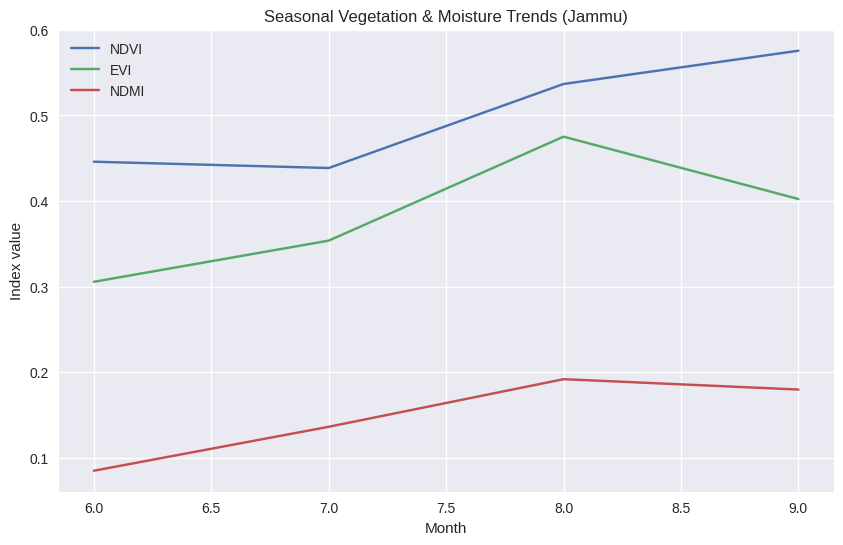

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(monthly_mean.index, monthly_mean["NDVI"], label="NDVI")
plt.plot(monthly_mean.index, monthly_mean["EVI"], label="EVI")
plt.plot(monthly_mean.index, monthly_mean["NDMI"], label="NDMI")
plt.xlabel("Month")
plt.ylabel("Index value")
plt.title("Seasonal Vegetation & Moisture Trends (Jammu)")
plt.legend()
plt.grid(True)
plt.show()


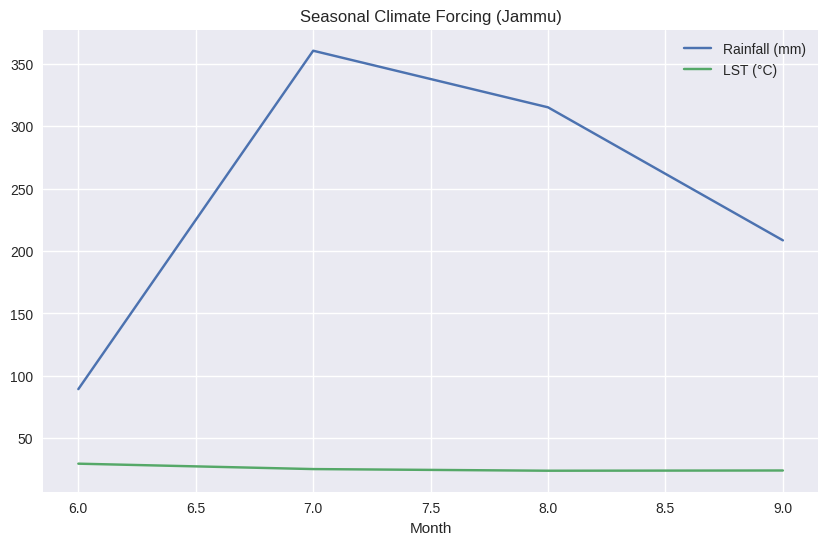

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(monthly_mean.index, monthly_mean["Rainfall"], label="Rainfall (mm)")
plt.plot(monthly_mean.index, monthly_mean["LST"], label="LST (°C)")
plt.xlabel("Month")
plt.title("Seasonal Climate Forcing (Jammu)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
features = [
    "NDVI", "EVI", "NDMI", "NDWI",
    "LST", "LST_anomaly",
    "Rainfall", "Rainfall_lag1"
]

corr = df[features].corr()


In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()


In [ ]:
yearly_ndvi = df.groupby("Year")["NDVI"].mean()

plt.figure(figsize=(8,5))
plt.plot(yearly_ndvi.index, yearly_ndvi.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Mean NDVI")
plt.title("Inter-annual Vegetation Trend (Jammu, Kharif)")
plt.grid(True)
plt.show()


In [ ]:
plt.figure(figsize=(9,5))
sns.boxplot(x="Month", y="NDVI", data=df)
plt.xlabel("Month (Kharif)")
plt.ylabel("NDVI")
plt.title("Seasonal NDVI Distribution (2017–2025)")
plt.show()


In [ ]:
plt.figure(figsize=(9,5))
sns.boxplot(x="Month", y="NDVI", data=df)
plt.xlabel("Month (Kharif)")
plt.ylabel("NDVI")
plt.title("Seasonal NDVI Distribution (2017–2025)")
plt.show()


In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df["Rainfall"], df["NDVI"], alpha=0.3)
plt.xlabel("Rainfall (mm)")
plt.ylabel("NDVI")
plt.title("Rainfall vs Vegetation Greenness")
plt.grid(True)
plt.show()


In [ ]:
features = [
    "NDVI", "EVI", "NDMI", "NDWI",
    "LST", "LST_anomaly",
    "Rainfall", "Rainfall_lag1"
]

corr = df[features].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Between Environmental Indicators")
plt.show()
